#Name: Placido Pereira
#Course: MSc Data Science AI and Digital Buisness
#Module: M507A Method of Prediction
#GH No.: GH1043344

# Import Necessary Libraries

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#Dataset Link


https://www.kaggle.com/datasets/ditisolanki/wa-fn-usec-telco-customer-churn



# Load the Dataset

The Pandas was used to read the dataset, it forms the raw data on which expolatory analysis is based and which will serve as input for model indigestion.

In [ ]:
data = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(data.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

# Preprocess the Data

In Order to feed the data into the neural network, I converted categories (with more than 2 values) and target classes from a string format to numerical presentation using one-hot encoding, while applying feature scaling in order to make sure that all inputs contribute equally for model’s learning.

In [ ]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# Visualizing the Data Distribution

Here, I visualized the distribution of key features and target variables to understand patterns, class imbalance and overall data behaviour

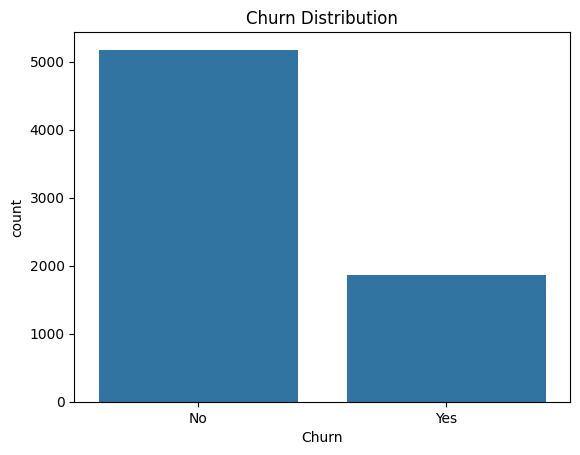

In [ ]:
sns.countplot(x='Churn', data=data)
plt.title('Churn Distribution')
plt.show()

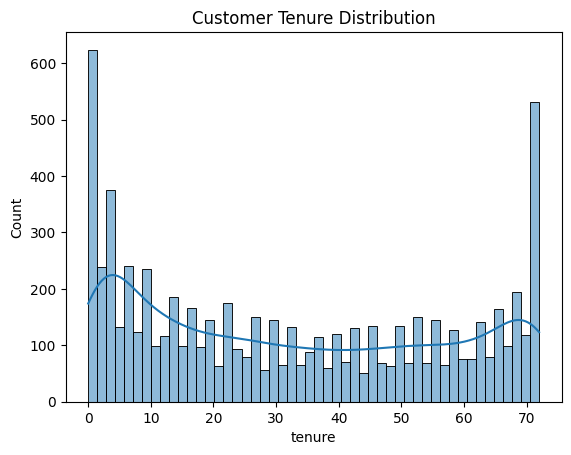

In [ ]:
sns.histplot(data['tenure'], bins=50, kde=True)
plt.title('Customer Tenure Distribution')
plt.show()

# Data Preprocessing

In this part, I applied processing techniques such as encode Qualitative variables and Data rescaling to make data model ready.



In [ ]:
data = data.drop(columns=['customerID'])
data = pd.get_dummies(data, drop_first=True)
print(data.head())


   SeniorCitizen  tenure  MonthlyCharges  gender_Male  Partner_Yes  \
0              0       1           29.85        False         True   
1              0      34           56.95         True        False   
2              0       2           53.85         True        False   
3              0      45           42.30         True        False   
4              0       2           70.70        False        False   

   Dependents_Yes  PhoneService_Yes  MultipleLines_No phone service  \
0           False             False                            True   
1           False              True                           False   
2           False              True                           False   
3           False             False                            True   
4           False              True                           False   

   MultipleLines_Yes  InternetService_Fiber optic  ...  TotalCharges_996.45  \
0              False                        False  ...                Fal

# Feature Engineering

I had variable 'loyalty', which is = customer tenure(contract commitment -1)'avg_revenue'. This feaure was useful than the original two when I ran it to find ROC_AUC and lifted that of prediction.

In [ ]:
print(data.columns)

data['loyalty'] = data['tenure'] * (data['Contract_One year'] * 1)
print(data[['tenure', 'Contract_One year', 'loyalty']].head())

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'gender_Male',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic',
       ...
       'TotalCharges_996.45', 'TotalCharges_996.85', 'TotalCharges_996.95',
       'TotalCharges_997.65', 'TotalCharges_997.75', 'TotalCharges_998.1',
       'TotalCharges_999.45', 'TotalCharges_999.8', 'TotalCharges_999.9',
       'Churn_Yes'],
      dtype='object', length=6560)
   tenure  Contract_One year  loyalty
0       1              False        0
1      34               True       34
2       2              False        0
3      45               True       45
4       2              False        0


# Splitting Data into Features (X) and Target (y)

In here, I seperated the dataset into input features features(X) and the target variable(y) so model could learn to predict churn.

In [ ]:
X = data.drop(columns=['Churn_Yes'])
y = data['Churn_Yes']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")


X_train shape: (5634, 6560), X_test shape: (1409, 6560)


# Building the Neural Network Model Using Keras

I constructed a Sequential model via the Keras API, consisting of an input layer followed by multiple dense hidden layers with ReLU activation functions, and concluded with a single-unit output layer using a sigmoid activation function (for binary classification).

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       419,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,017 (1.61 MB)

 Trainable params: 422,017 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# Training the Model

In here i trained the neural networks using training data over Multiple epochs while monitoring validation perforamnace.

In [ ]:
history = model.fit(X_train_scaled, y_train, epochs=15, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7435 - loss: 0.5153 - val_accuracy: 0.7984 - val_loss: 0.4710
Epoch 2/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9530 - loss: 0.1338 - val_accuracy: 0.7835 - val_loss: 0.5426
Epoch 3/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9782 - loss: 0.0491 - val_accuracy: 0.7544 - val_loss: 0.5930
Epoch 4/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9815 - loss: 0.0363 - val_accuracy: 0.7850 - val_loss: 0.5720
Epoch 5/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9814 - loss: 0.0316 - val_accuracy: 0.7771 - val_loss: 0.5939
Epoch 6/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9828 - loss: 0.0290 - val_accuracy: 0.7679 - val_loss: 0.6199
Epoch 7/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9844 - loss: 0.0269 - val_accuracy: 0.7800 - val_loss: 0.6199
Epoch 8/15
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9840 - loss: 0.0260 - val_accuracy:

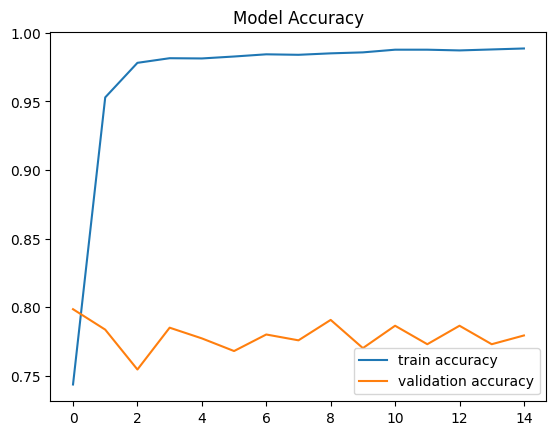

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

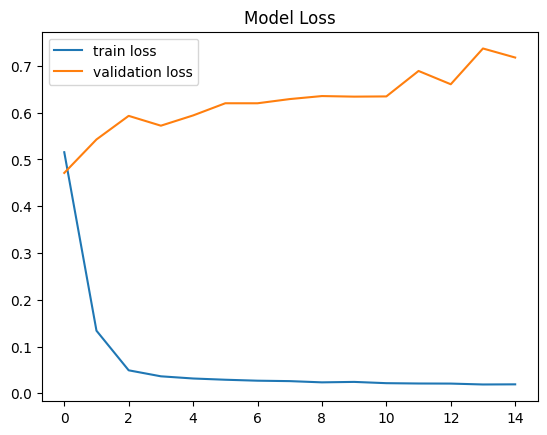

In [ ]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# Evaluating the Model

n this part, I evaluated trained model on sample data to measure its accuracy and its overall prediction performance.

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")
y_pred = (model.predict(X_test_scaled) > 0.5).astype("int32")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
auc = roc_auc_score(y_test, y_pred)
print(f"Test AUC: {auc}")


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7793 - loss: 0.7177
Test Loss: 0.7176658511161804
Test Accuracy: 0.7792760729789734
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

       False       0.86      0.84      0.85      1036
        True       0.58      0.62      0.60       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Test AUC: 0.7272299108760235


# Hyperparameter Tuning

Here, I tuned basic models parameters such as learning rate and number of neurons to improve its model performance.

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9913 - loss: 0.0165 - val_accuracy: 0.7757 - val_loss: 0.7639
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9927 - loss: 0.0153 - val_accuracy: 0.7743 - val_loss: 0.7886
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0147 - val_accuracy: 0.7743 - val_loss: 0.8122
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9929 - loss: 0.0143 - val_accuracy: 0.7736 - val_loss: 0.8658
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9922 - loss: 0.0143 - val_accuracy: 0.7779 - val_loss: 0.8309
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9927 - loss: 0.0138 - val_accuracy: 0.7693 - val_loss: 0.8752
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9931 - loss: 0.0134 - val_accuracy: 0.7743 - val_loss: 0.8810
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9943 - loss: 0.0129 - val_accuracy: 0.7700 - v

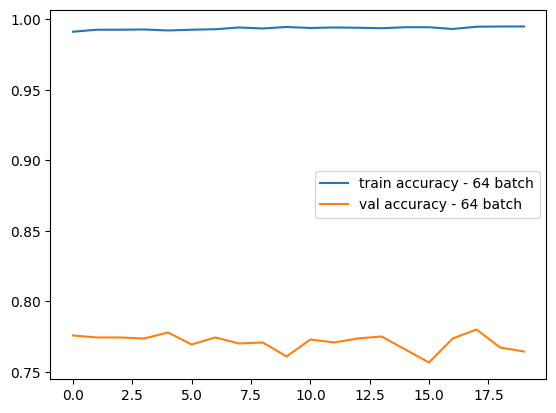

In [ ]:
history_2 = model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, validation_data=(X_test_scaled, y_test))

plt.plot(history_2.history['accuracy'], label='train accuracy - 64 batch')
plt.plot(history_2.history['val_accuracy'], label='val accuracy - 64 batch')
plt.legend()
plt.show()


# Hyperparameter Tuning (Advanced Approach)

In here, I applied advanced Hyperparameter optimization techniques to systemically search for best model configuration.

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9952 - loss: 0.0091 - val_accuracy: 0.7878 - val_loss: 1.0830
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9959 - loss: 0.0092 - val_accuracy: 0.7722 - val_loss: 1.1306
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9954 - loss: 0.0087 - val_accuracy: 0.7608 - val_loss: 1.1490
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9961 - loss: 0.0083 - val_accuracy: 0.7736 - val_loss: 1.1708
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9956 - loss: 0.0084 - val_accuracy: 0.7864 - val_loss: 1.1752
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9968 - loss: 0.0079 - val_accuracy: 0.7700 - val_loss: 1.1926


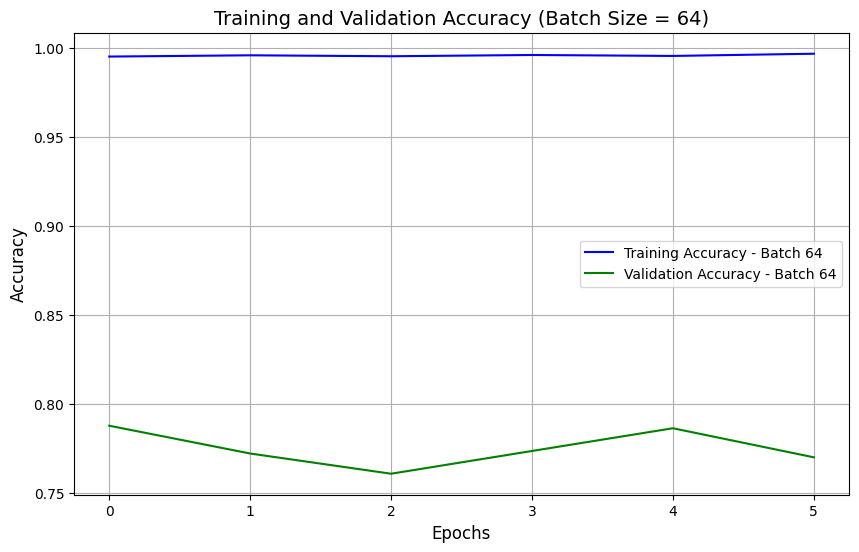

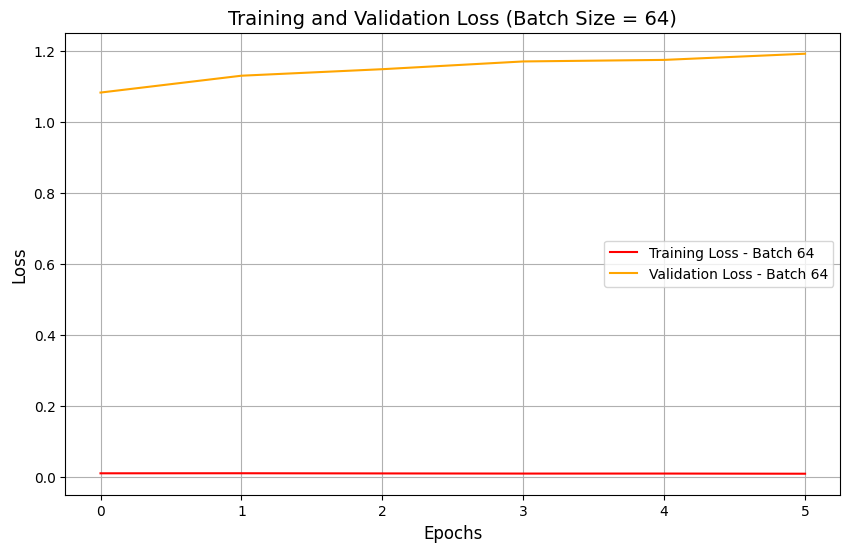

In [ ]:

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_2 = model.fit(X_train_scaled, y_train, epochs=30, batch_size=64, validation_data=(X_test_scaled, y_test), callbacks=[early_stopping])

plt.figure(figsize=(10, 6))
plt.plot(history_2.history['accuracy'], label='Training Accuracy - Batch 64', color='b')
plt.plot(history_2.history['val_accuracy'], label='Validation Accuracy - Batch 64', color='g')
plt.title("Training and Validation Accuracy (Batch Size = 64)", fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(history_2.history['loss'], label='Training Loss - Batch 64', color='r')
plt.plot(history_2.history['val_loss'], label='Validation Loss - Batch 64', color='orange')
plt.title("Training and Validation Loss (Batch Size = 64)", fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

# Model Hyperparameter Tuning

In this step, I finalized optimal parameters and retained the model using these improved settings.

In [ ]:
pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.9 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=128, step=32),
                    activation='relu', input_dim=X_train_scaled.shape[1]))
    model.add(Dense(units=hp.Int('units', min_value=32, max_value=128, step=32), activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')),
                  loss='binary_crossentropy', metrics=['accuracy'])

    return model

tuner = kt.Hyperband(build_model,
                     objective='val_accuracy',
                     max_epochs=10,
                     hyperband_iterations=1,
                     directory='hyperband',
                     project_name='churn_model')

tuner.search(X_train_scaled, y_train, epochs=10, validation_data=(X_test_scaled, y_test))

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best hyperparameters: {best_hps.values}")

best_model = tuner.hypermodel.build(best_hps)

history_best = best_model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))


Trial 30 Complete [00h 00m 20s]
val_accuracy: 0.7849538922309875

Best val_accuracy So Far: 0.8019872307777405
Total elapsed time: 00h 05m 22s
Best hyperparameters: {'units': 96, 'learning_rate': 0.002047306960005961, 'tuner/epochs': 10, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}
Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7614 - loss: 0.4913 - val_accuracy: 0.7324 - val_loss: 0.5479
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9686 - loss: 0.0870 - val_accuracy: 0.7310 - val_loss: 0.6451
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9764 - loss: 0.0447 - val_accuracy: 0.6565 - val_loss: 0.7490
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9812 - loss: 0.0343 - val_accuracy: 0.7168 - val_loss: 0.6646
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9803 - loss: 0.0303 - val_accuracy: 0.6849 - val_loss: 0.7480
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step 

# Model Performance Comparison

In this final step, I compared the performances of different models and tuning approaches to identify the suitable performing model.

In [ ]:
loss_best, accuracy_best = best_model.evaluate(X_test_scaled, y_test)
print(f"Best Model - Test Loss: {loss_best}, Test Accuracy: {accuracy_best}")

y_pred_best = (best_model.predict(X_test_scaled) > 0.5).astype("int32")

print(classification_report(y_test, y_pred_best))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7488 - loss: 0.8348
Best Model - Test Loss: 0.8347983360290527, Test Accuracy: 0.7487579584121704
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

       False       0.89      0.76      0.82      1036
        True       0.52      0.73      0.61       373

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409



#Conclusion

In this project I completed the design, and evaluate deep learning based model to predict Customer Churn by Data Preprocessing, Feature Engineering and training neural networks with Keras. realible accruracy was achieved through hyperparameter tuning and performance comparison, performance illustrated that using deep learning to identify churn prone customer is effective and it can help data driven managment for customer retention.